In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict

from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str
    
    


In [5]:
def create_outline(state:BlogState)->BlogState:
    
    title=state['title']
    
    prompt=f"Generate a detailed blog  outline on the given topic - {title}"
    
    outline=model.invoke(prompt).content
    state['outline']=outline
    return state

In [6]:
def create_content(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']
    
    prompt=f"generate a blog for the topic {title} for the given outline -{outline}"
    
    content=model.invoke(prompt).content
    state['content']=content
    return state

In [7]:
graph=StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_content',create_content)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_content')
graph.add_edge('create_content',END)

workflow=graph.compile()

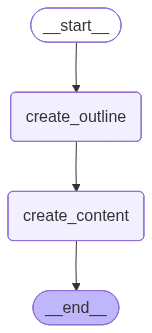

In [8]:
workflow

In [9]:
initial_state={'title':'Difference in Generative AI and Agentic AI'}

final_state=workflow.invoke(initial_state)
print(final_state['title'])


Difference in Generative AI and Agentic AI


In [10]:
print(final_state['outline'])


Okay, here's a detailed blog outline comparing Generative AI and Agentic AI, designed to be comprehensive, engaging, and easy to follow for a general tech-savvy audience.

---

## Blog Title: Beyond Creation: Understanding the Core Differences Between Generative AI and Agentic AI

**Subtitle:** From Crafting Content to Taking Action: How Two Powerful AI Paradigms Are Shaping Our Future

---

### I. Introduction: The Evolving Landscape of Artificial Intelligence (50-100 words)

*   **Hook:** AI is no longer a monolithic concept. We hear about AI creating art, writing code, and also about AI driving cars and managing complex systems. What's the difference?
*   **Briefly Define AI:** An umbrella term for machines performing tasks that typically require human intelligence.
*   **Introduce the Two Stars:** Generative AI (the creator) and Agentic AI (the doer/decider).
*   **Thesis Statement:** While often confused or seen as interchangeable, Generative AI and Agentic AI represent distinct p

In [11]:
print(final_state['content'])

# Beyond Creation: Understanding the Core Differences Between Generative AI and Agentic AI

**From Crafting Content to Taking Action: How Two Powerful AI Paradigms Are Shaping Our Future**

---

### I. Introduction: The Evolving Landscape of Artificial Intelligence

Artificial Intelligence is no longer a monolithic concept confined to science fiction. Today, we hear about AI creating stunning art, writing complex code, and even driving cars or managing intricate logistical systems. But what differentiates these incredible feats? At its core, AI remains an umbrella term for machines performing tasks that typically require human intelligence. Yet, within this vast field, two powerful paradigms are rapidly evolving: **Generative AI** (the master creator) and **Agentic AI** (the intelligent doer and decider). While often confused or seen as interchangeable, these two represent distinct approaches with different core functions, mechanisms, and applications. Understanding their unique streng